# Laboratorio 8 - Maquinas Vectoriales de Soporte (SVM)
### CC3074 - Mineria de Datos | Universidad del Valle de Guatemala
### SmartStay Advisors

## Librerias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn import metrics, set_config
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.style.use('ggplot')

## Actividad 1. Uso de los mismos conjuntos de entrenamiento y prueba de hojas anteriores

In [ ]:
result = pyreadr.read_r('data/listings.RData')
df = result[list(result.keys())[0]]
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [ ]:
# Limpieza de precio (igual que hojas anteriores)
if df['price'].dtype == object:
    df['price'] = df['price'].astype(str).str.replace(r'[$,]', '', regex=True).str.strip()
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
else:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna(subset=['price'])
df = df[df['price'] > 0]
df = df[df['price'] <= 1000]  # filtro de outliers aplicado en labs anteriores

print(f"Filas despues de limpieza: {len(df)}")
print(f"Precio min: ${df['price'].min():.2f} | max: ${df['price'].max():.2f} | promedio: ${df['price'].mean():.2f}")

Filas despues de limpieza: 72284
Precio min: $8.00 | max: $1000.00 | promedio: $237.92


## Actividad 2. Exploracion de datos y transformaciones para SVM

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72284 entries, 0 to 164212
Data columns (total 80 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            72284 non-null  float64
 1   listing_url                                   72284 non-null  object 
 2   scrape_id                                     72284 non-null  float64
 3   last_scraped                                  72284 non-null  object 
 4   source                                        72284 non-null  object 
 5   name                                          72284 non-null  object 
 6   description                                   72284 non-null  object 
 7   neighborhood_overview                         72284 non-null  object 
 8   picture_url                                   72284 non-null  object 
 9   host_id                                       72284 non-null  int

In [ ]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0].sort_values(ascending=False))

Valores nulos por columna:
calendar_updated                72284
neighbourhood_group_cleansed    37143
review_scores_rating            11554
review_scores_value             11554
review_scores_location          11554
review_scores_communication     11554
review_scores_checkin           11554
review_scores_cleanliness       11554
review_scores_accuracy          11554
reviews_per_month               11554
license                         10212
host_total_listings_count         627
host_listings_count               627
bedrooms                          106
beds                               72
maximum_maximum_nights             47
minimum_maximum_nights             47
maximum_minimum_nights             47
minimum_minimum_nights             47
bathrooms                          12
dtype: int64


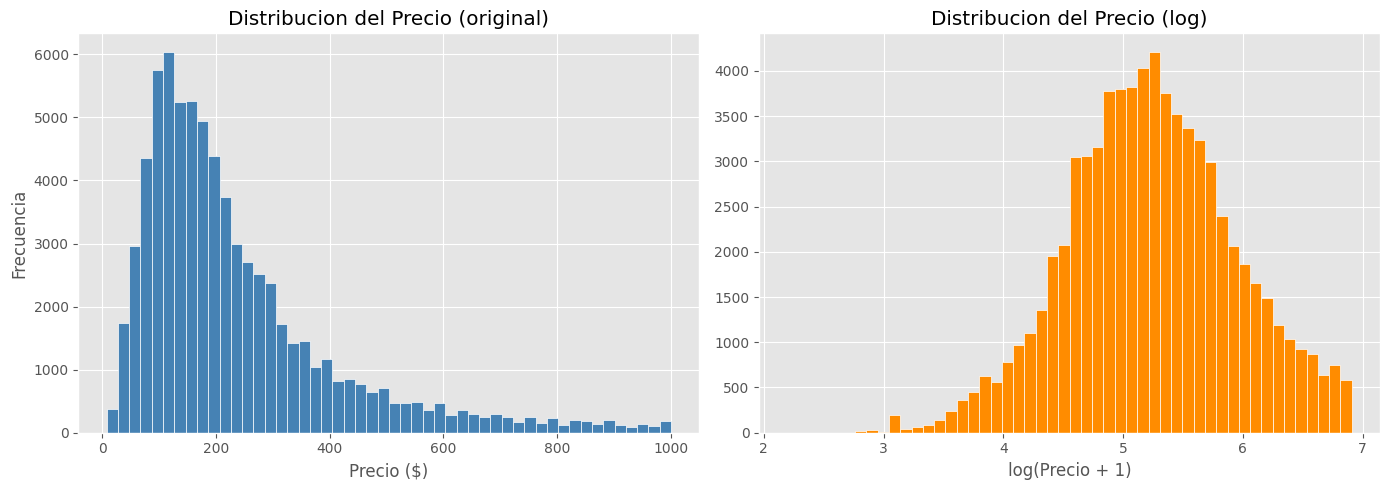

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion del Precio (original)')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['price']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribucion del Precio (log)')
axes[1].set_xlabel('log(Precio + 1)')
plt.tight_layout()
plt.show()

In [ ]:
# Seleccion de variables (mismas usadas en labs anteriores)
columnas_numericas = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'number_of_reviews', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'calculated_host_listings_count', 'availability_365'
]
columnas_categoricas = ['neighbourhood_cleansed', 'property_type', 'room_type']

columnas_numericas   = [c for c in columnas_numericas   if c in df.columns]
columnas_categoricas = [c for c in columnas_categoricas if c in df.columns]

print("Variables numericas:",   columnas_numericas)
print("\nVariables categoricas:", columnas_categoricas)
print("""
Transformaciones necesarias para SVM:
  - Normalizacion con StandardScaler (SVM es sensible a la escala).
  - Imputacion de nulos: mediana para numericas, moda para categoricas.
  - Codificacion OneHot para variables categoricas.
  - Uso de submuestra para kernels no lineales (complejidad O(n^2)).
""")

Variables numericas: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'availability_365']

Variables categoricas: ['neighbourhood_cleansed', 'property_type', 'room_type']

Transformaciones necesarias para SVM:
  - Normalizacion con StandardScaler (SVM es sensible a la escala).
  - Imputacion de nulos: mediana para numericas, moda para categoricas.
  - Codificacion OneHot para variables categoricas.
  - Uso de submuestra para kernels no lineales (complejidad O(n^2)).



In [ ]:
# Pipeline de preprocesamiento
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocesador = ColumnTransformer([
    ('numerico',   numeric_preprocessor,     columnas_numericas),
    ('categorico', categorical_preprocessor, columnas_categoricas)
], remainder='drop')

print("Preprocesador configurado.")

Preprocesador configurado.


## Actividad 3. Variable respuesta categorica de precio

In [ ]:
# Percentiles 33 y 66, consistente con labs anteriores
p33 = df['price'].quantile(0.33)
p66 = df['price'].quantile(0.66)
print(f"Percentil 33: ${p33:.2f}  |  Percentil 66: ${p66:.2f}")

def categorizar_precio(precio):
    if precio <= p33:
        return 'Economica'
    elif precio <= p66:
        return 'Intermedia'
    else:
        return 'Cara'

df['price_category'] = df['price'].apply(categorizar_precio)
print("\nDistribucion de categorias:")
print(df['price_category'].value_counts())

Percentil 33: $136.00  |  Percentil 66: $246.00

Distribucion de categorias:
price_category
Cara          24503
Intermedia    23903
Economica     23878
Name: count, dtype: int64


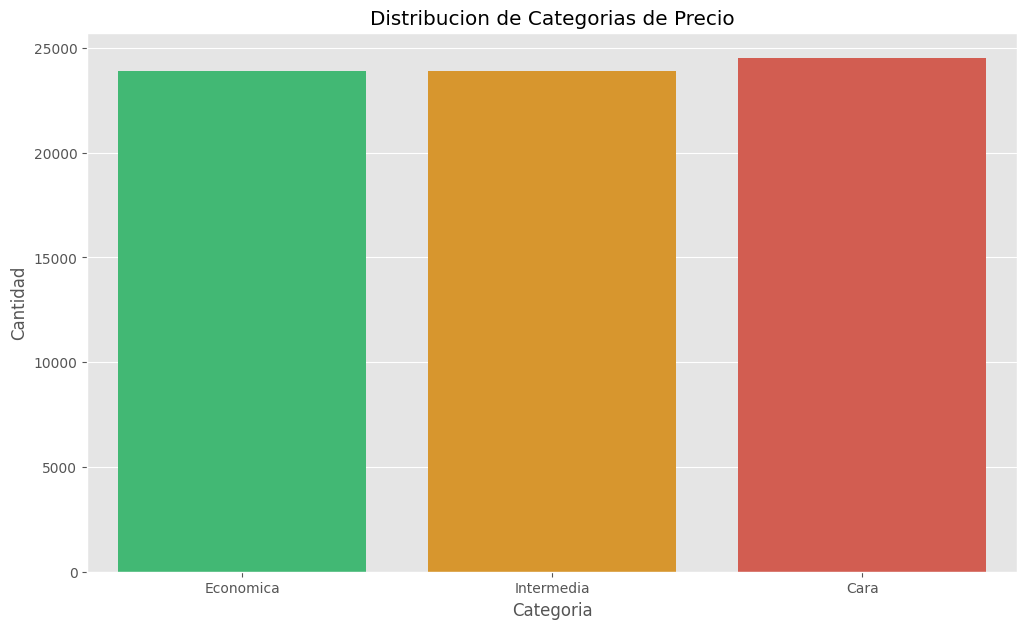

In [ ]:
cat_counts = df['price_category'].value_counts().reset_index()
cat_counts.columns = ['Categoria', 'Cantidad']
sb.barplot(x='Categoria', y='Cantidad', data=cat_counts,
           palette=['#2ecc71', '#f39c12', '#e74c3c'],
           order=['Economica', 'Intermedia', 'Cara'])
plt.title('Distribucion de Categorias de Precio')
plt.show()

In [ ]:
# Division de datos: 80/20 con random_state=42 (mismos que labs anteriores)
todas_variables = columnas_numericas + columnas_categoricas
X       = df[todas_variables].copy()
y_class = df['price_category'].copy()
y_reg   = df['price'].copy()

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.20, random_state=42, stratify=y_class
)
y_train_reg = y_reg.loc[X_train.index]
y_test_reg  = y_reg.loc[X_test.index]

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 57827 filas (80%)
Test:  14457 filas (20%)


In [ ]:
# Submuestra para kernels no lineales (SVC es O(n^2))
MAX_TRAIN_SVC = 5000

if len(X_train) > MAX_TRAIN_SVC:
    X_train_svc, _, y_train_svc, _ = train_test_split(
        X_train, y_train_class,
        train_size=MAX_TRAIN_SVC,
        random_state=42,
        stratify=y_train_class
    )
    print(f"Submuestra para kernels no lineales: {X_train_svc.shape[0]} filas")
else:
    X_train_svc = X_train
    y_train_svc = y_train_class

Submuestra para kernels no lineales: 5000 filas


## Funcion de evaluacion

In [ ]:
CLASES = ['Economica', 'Intermedia', 'Cara']
resultados_clasificacion = []

def evaluar_clasificacion(modelo, X_tr, y_tr, X_te, y_te, nombre):
    inicio = time.time()
    modelo.fit(X_tr, y_tr)
    tiempo = time.time() - inicio

    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    acc_tr  = metrics.accuracy_score(y_tr, y_pred_tr)
    acc_te  = metrics.accuracy_score(y_te, y_pred_te)
    prec    = metrics.precision_score(y_te, y_pred_te, average='weighted', zero_division=0)
    rec     = metrics.recall_score(y_te,    y_pred_te, average='weighted', zero_division=0)
    f1      = metrics.f1_score(y_te,         y_pred_te, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f" {nombre}")
    print(f"{'='*55}")
    print(f" Accuracy Train : {acc_tr:.4f}")
    print(f" Accuracy Test  : {acc_te:.4f}")
    print(f" Diferencia     : {acc_tr - acc_te:.4f}")
    print(f" Precision      : {prec:.4f}")
    print(f" Recall         : {rec:.4f}")
    print(f" F1-Score       : {f1:.4f}")
    print(f" Tiempo (s)     : {tiempo:.2f}")
    print(f" Sobreajuste    : {'Si' if acc_tr - acc_te > 0.05 else 'No'}")
    print("\nReporte de Clasificacion:")
    print(classification_report(y_te, y_pred_te, target_names=CLASES, zero_division=0))

    cm = confusion_matrix(y_te, y_pred_te, labels=CLASES)
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
    plt.tight_layout()
    plt.show()

    return {
        'Modelo':      nombre,
        'Acc_Train':   round(acc_tr, 4),
        'Acc_Test':    round(acc_te, 4),
        'Diferencia':  round(acc_tr - acc_te, 4),
        'F1':          round(f1,  4),
        'Precision':   round(prec, 4),
        'Recall':      round(rec, 4),
        'Tiempo_s':    round(tiempo, 2),
        'Sobreajuste': 'Si' if acc_tr - acc_te > 0.05 else 'No'
    }